In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [10]:
df=pd.read_csv("practice-hours-assessment-score[1].csv")

In [11]:
df.head()

,Practice_Hours,Assessment_Score
0,1.0,55.025
1,1.4,46.706
2,1.9,57.018
3,2.3,64.732
4,2.8,55.269


Text(0, 0.5, 'Assessment_Score')

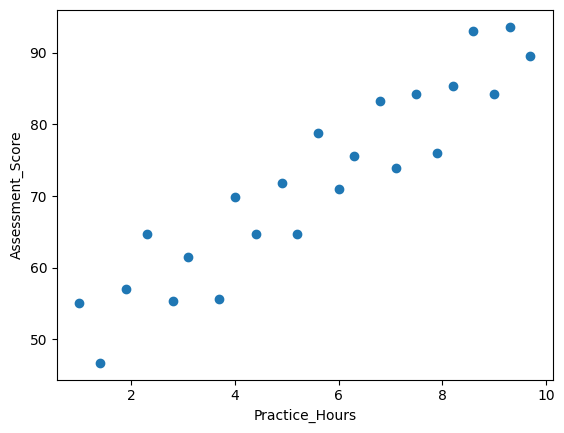

In [18]:
# Scatter plot
plt.scatter(df['Practice_Hours'],df['Assessment_Score'])
plt.xlabel("Practice_Hours")
plt.ylabel("Assessment_Score")

In [19]:
#Correlation
df.corr()

,Practice_Hours,Assessment_Score
Practice_Hours,1.000000,0.931142
Assessment_Score,0.931142,1.000000


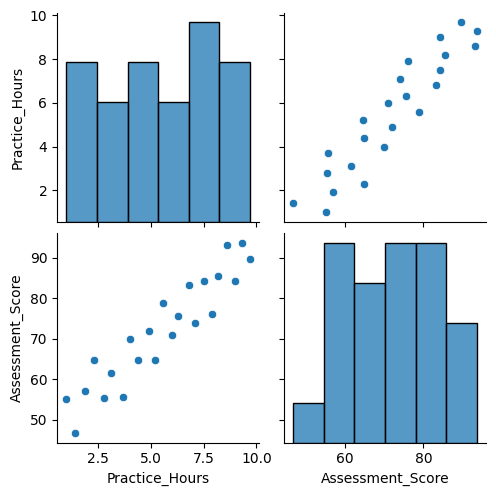

In [21]:
import seaborn as sns
sns.pairplot(df)

In [37]:
#independent and dependent features
X=df[["Practice_Hours"]] #Independent features should be DF
y=df["Assessment_Score"] #dependent

In [27]:
X.shape

(23, 1)

In [38]:
y.shape

(23,)

In [31]:
X_series=df['Practice_Hours']
X_series.shape

(23,)

In [41]:
# Train and Test Split
from sklearn.model_selection import train_test_split

In [54]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=32)                                   

In [55]:
X_train

,Practice_Hours
15,7.1
0,1.0
13,6.3
2,1.9
12,6.0
18,8.2
1,1.4
22,9.7
4,2.8
9,4.9


In [60]:
#standardization(z-score)
from sklearn.preprocessing import StandardScaler

In [124]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_train

array([[ 0.71876158],
       [-1.51954401],
       [ 0.42521331],
       [-1.1893022 ],
       [ 0.31513271],
       [ 1.12239046],
       [-1.37276987],
       [ 1.67279348],
       [-0.85906039],
       [-0.08849617],
       [ 0.02158443],
       [ 1.52601934],
       [-1.04252806],
       [-0.41873798],
       [ 1.2691646 ],
       [-0.74897979],
       [ 0.16835857]])

In [125]:
X_test=scaler.transform(X_test)
X_test

array([[ 0.86553572],
       [-0.27196384],
       [ 0.60868098],
       [ 1.41593874],
       [ 1.01230986],
       [-0.52881858]])

In [126]:
#Apply Simple Linear Regression
from sklearn.linear_model import LinearRegression

In [127]:
regression=LinearRegression(n_jobs=-1)

In [128]:
regression.fit(X_train,y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",-1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[12.77]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,71.04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[4.12]


In [129]:
print("Coefficient or slope",regression.coef_)
print("intercept",regression.intercept_)

Coefficient or slope [12.76653038]
intercept 71.0444705882353


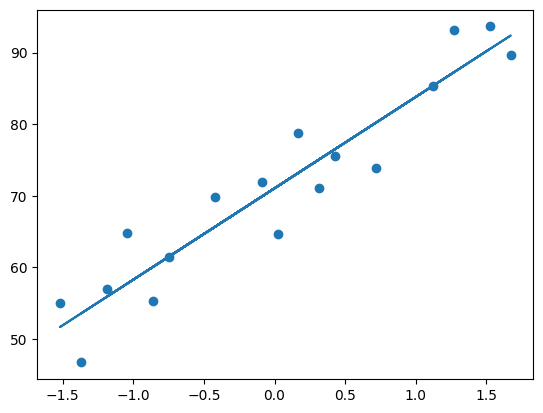

In [130]:
#plot training data best fit line
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train))

In [131]:
# Prediction for test data
y_pred=regression.predict(X_test)

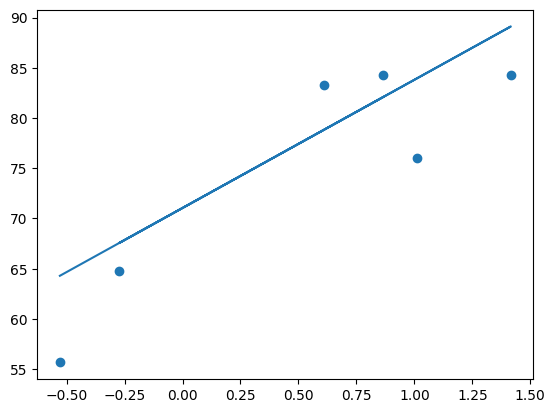

In [132]:
plt.scatter(X_test,y_test)
plt.plot(X_test,y_pred)

In [104]:
#Performance metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [108]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)

In [109]:
print(mse)
print(mae)
print(rmse)

32.36594446077888
5.157234191653777
5.689107527616162


In [110]:
from sklearn.metrics import r2_score

In [113]:
score=r2_score(y_test,y_pred)
print(score)

0.7303913734970773


In [115]:
%pip install statsmodels

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.3 MB 1.8 MB/s eta 0:00:06
   ---- ----------------------------------- 1.3/11.3 MB 2.0 MB/s eta 0:00:05
   ----- ---------------------------------- 1.6/11.3 MB 2.0 MB/s eta 0:00:05
   ------- -------------------------------- 2.1/11.3 MB 2.0 MB/s eta 0:00:05
   -------- ------------------------------- 2.4/11.3 MB 2.0 MB/s eta 0:00:05
   --------- ------------------------------ 2.6/11.3 MB 1.7 MB/s eta 0:00:05
   ---------- ----------------------------- 2.9/11.3 MB 1.8 MB/s eta 0:00:05
   ----------- ---------------------------- 3.1/11.3 MB 1.8 MB/s eta 0:00:05
   ------------ --------------------------- 3.4/11.3 MB 1.7 MB/s eta 0:00:05
   ------------ --------------------------- 3.7/11.3 MB 1.7 MB/s eta 0:00:05
   -------------- ------------------------- 4.2/11.3 MB 1.7 MB/s eta 0:00:05
   ----------


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [116]:
#OLS Linear Regression
import statsmodels.api as sm

In [117]:
model=sm.OLS(y_train,X_train).fit()

In [118]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:       Assessment_Score   R-squared (uncentered):                   0.031
Model:                            OLS   Adj. R-squared (uncentered):             -0.029
Method:                 Least Squares   F-statistic:                             0.5146
Date:                Fri, 04 Sep 2026   Prob (F-statistic):                       0.483
Time:                        21:07:46   Log-Likelihood:                         -96.631
No. Observations:                  17   AIC:                                      195.3
Df Residuals:                      16   BIC:                                      196.1
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [133]:
regression.predict(scaler.transform([[7]]))

array([160.41018323])